In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('/workspaces/ds-fall-2025-wed-AS/Week-03-EDA-and-Dashboards/data/movie_ratings.csv')

In [15]:
print(df.shape)
print(df.info())
print(df.describe())

(212559, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 212559 entries, 0 to 212594
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   user_id      212559 non-null  int64  
 1   movie_id     212559 non-null  int64  
 2   rating       212559 non-null  int64  
 3   timestamp    212559 non-null  object 
 4   age          212559 non-null  int64  
 5   gender       212559 non-null  object 
 6   occupation   212559 non-null  object 
 7   zip_code     212559 non-null  object 
 8   title        212559 non-null  object 
 9   year         212559 non-null  float64
 10  decade       212559 non-null  float64
 11  genres       212559 non-null  object 
 12  rating_year  212559 non-null  int64  
 13  high_rating  212559 non-null  bool   
dtypes: bool(1), float64(2), int64(5), object(6)
memory usage: 22.9+ MB
None
             user_id       movie_id         rating            age  \
count  212559.000000  212559.000000  212559.000

In [16]:
df.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,year,decade,genres,rating_year,high_rating
0,196,242,3,1997-12-04 15:55:49,49,M,writer,55105,Kolya (1996),1996.0,1990.0,Comedy,1997,False
1,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Crime,1998,False
2,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Film-Noir,1998,False
3,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Mystery,1998,False
4,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Thriller,1998,False


In [3]:
df.isnull().sum()

user_id         0
movie_id        0
rating          0
timestamp       0
age             0
gender          0
occupation      0
zip_code        0
title           0
year           36
decade         36
genres          0
rating_year     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
print(f'Shape before dropping NA: {df.shape}')

df = df.dropna()

print(f'Shape after dropping NA: {df.shape}')

df.isnull().sum()

Shape before dropping NA: (212595, 13)
Shape after dropping NA: (212559, 13)


user_id        0
movie_id       0
rating         0
timestamp      0
age            0
gender         0
occupation     0
zip_code       0
title          0
year           0
decade         0
genres         0
rating_year    0
dtype: int64

# Question 1: What's the breakdown of genres for the movies that were rated?


When ordered by frequency using a countplot, the chart shows how ratings are distributed across genres.  
This highlights which genres are most common in the dataset and which are less represented independent of rating quality.


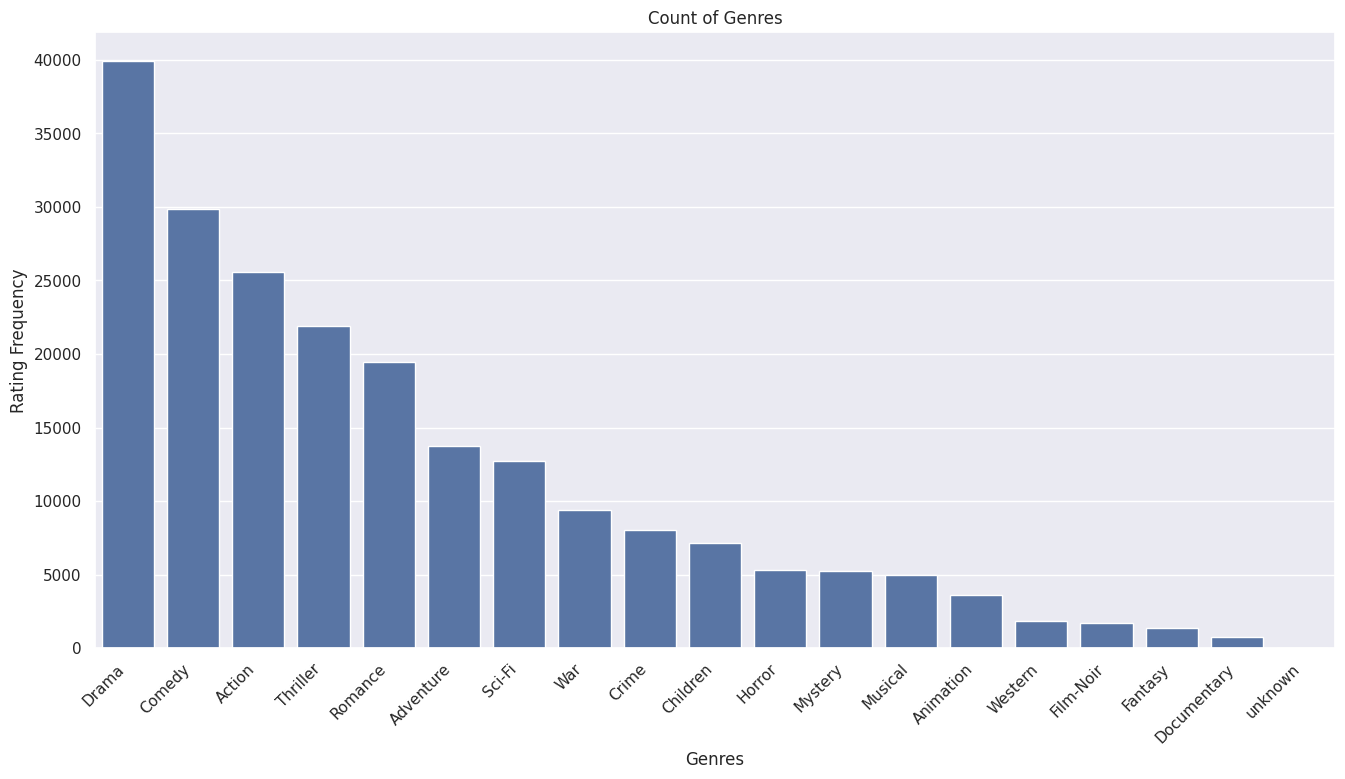

In [6]:

sns.set()
plt.figure(figsize=(16,8))
ax = sns.countplot(data=df, x='genres', order= df['genres'].value_counts().index)
ax.set_title("Count of Genres")
plt.xticks(rotation=45, ha='right')

plt.xlabel("Genres")
plt.ylabel("Rating Frequency")
plt.show()

# Question 2: Which genres have the highest viewer satisfaction (highest ratings)



Viewer satisfaction was sorted and measured in two ways: 

1. Getting the overall average from the genres ratings
2. Getting the average using only ratings of 4 and above to represent a "high rating" to compare only how many satisfied viewers instead of mixing unsatisfied or average

Both metrics produce similar trends, but the proportion of high ratings is a more direct measure of satisfaction.


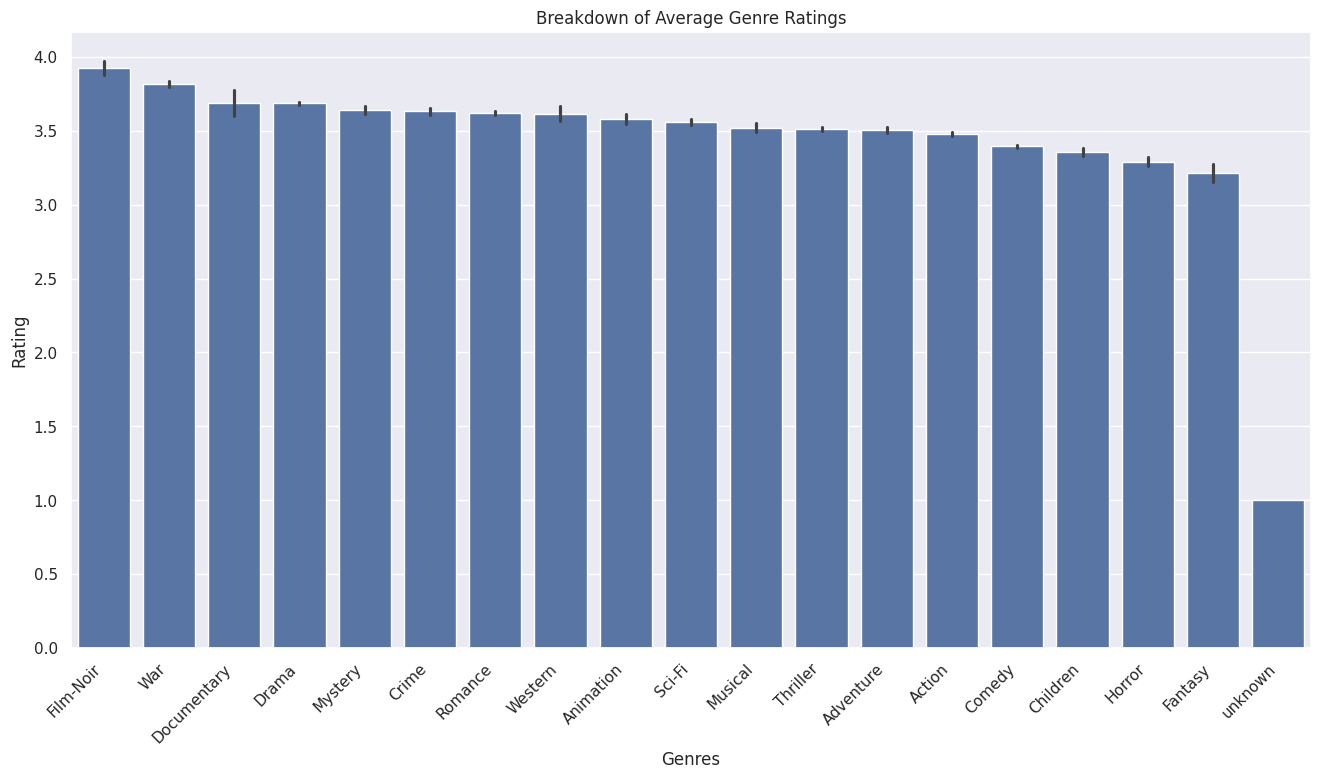

In [7]:
sns.set()
filter = df.groupby('genres')['rating'].mean().sort_values(ascending=False).index


plt.figure(figsize=(16, 8))
ax = sns.barplot(data=df, 
                     x='genres', 
                     y='rating',
                     order=filter 
                     
                      
                     )
ax.set_title("Breakdown of Average Genre Ratings")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("Rating")

plt.show()

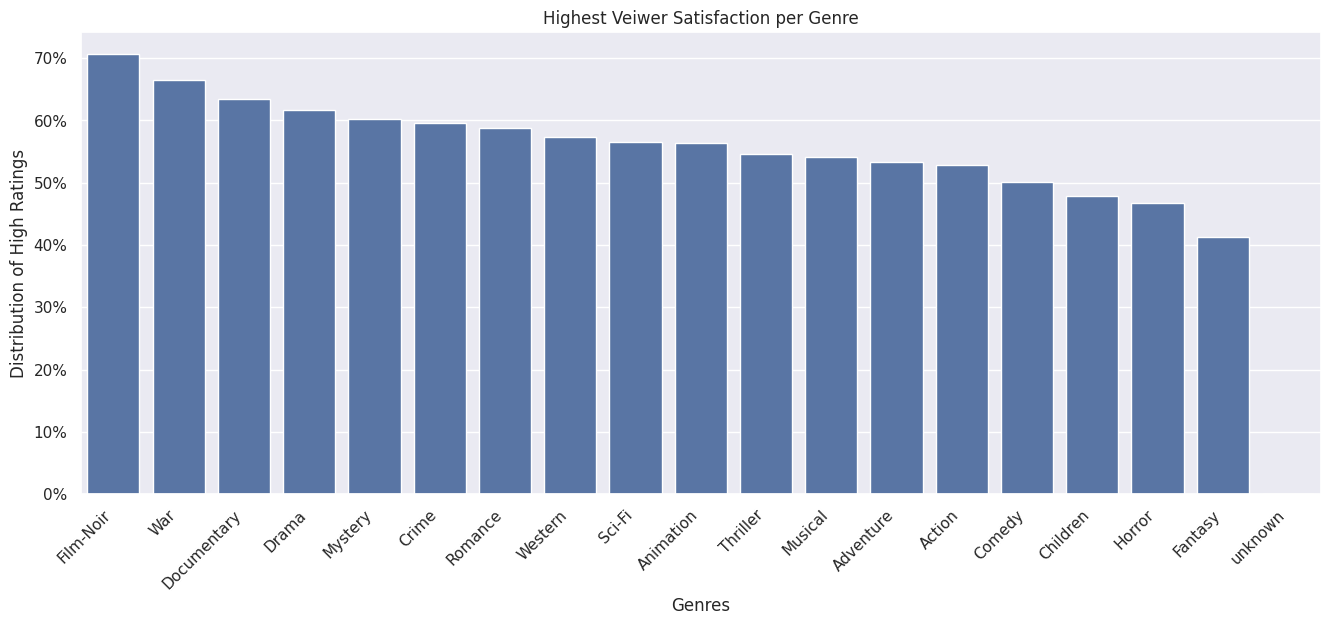

In [8]:
import matplotlib.ticker as mtick

sns.set()
plt.figure(figsize=(16,6))

df['high_rating'] = df['rating'] >= 4
satisfied_filter = df.groupby('genres')['high_rating'].mean().sort_values(ascending=False)

ax = sns.barplot(x=satisfied_filter.index ,
            y=satisfied_filter.values,
         )
#lets the y axis be a percentage instead of decimal values
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 


ax.set_title("Highest Veiwer Satisfaction per Genre")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("Distribution of High Ratings")

plt.show()



# Question 3:How does mean rating change across movie release years

A line plot was used to show the mean rating for each release year.  
This allows us to see how audience perception, revealing both short-term fluctuations and long-term trends.  

We can anayze and notice how some years show spikes or dips due due to fewer movies released that year or outliers, while years with many releases give more stable average ratings.  


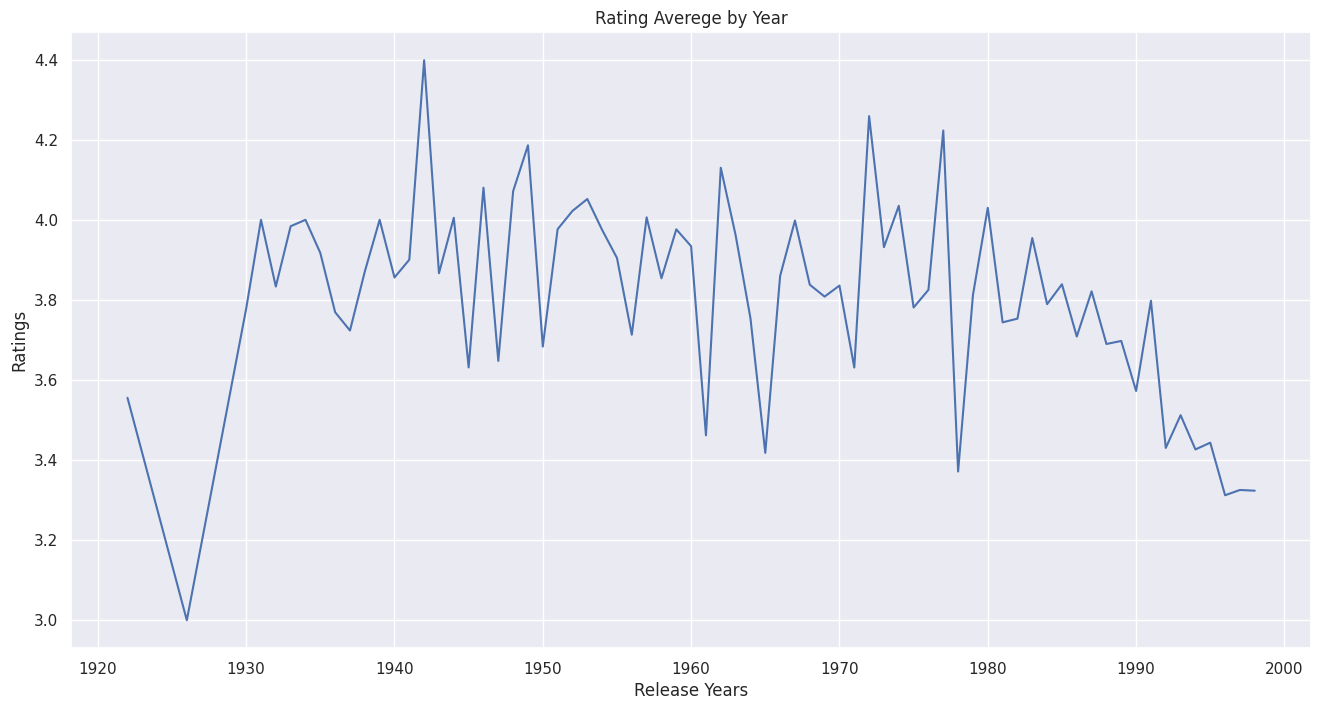

In [9]:
sns.set()

grouped_data = df.groupby('year')['rating'].mean().reset_index()

plt.figure(figsize=(16,8))
ax = sns.lineplot(data=grouped_data,
             x='year',
             y='rating')

plt.xlabel("Release Years")
plt.ylabel("Ratings")

ax.set_title("Rating Averege by Year")

plt.show()

# Question 4: What are the 5 best-rated movies that have at least 50 ratings? At least 150 ratings?

We grouped the data by movie title for total and averge number of the ratings and reset the index to allow for the title to become its own column

From this grouped dataset, two filters were created: one for movies with at least 50 ratings and another for movies with at least 150 ratings.
For each we grabbed the top 5 movies by average rating.

Two bar plots were made with these filters and showed a change in rankings when the rating threshold was increased

The higher threshold with a minimum of 150 ratings affirms movies with a broader concensus among the audience where as when we get lower, niche movies that are apricated by a smaller crowd might jump up in the rankings.

In general, the smaller the dataset the better possibility of outliers being represented in the rankings


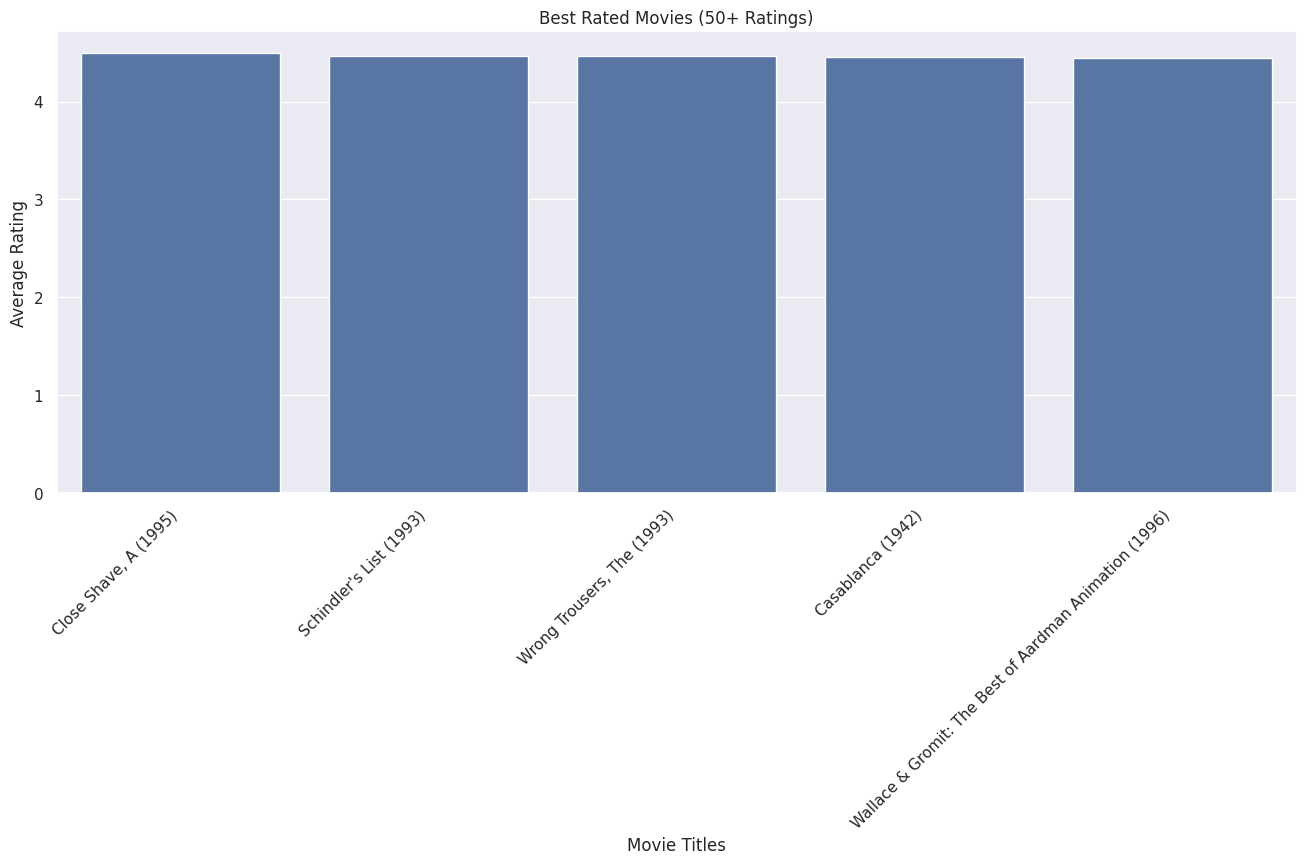

In [12]:
rating_filer = df.groupby('title')['rating'].agg(['count','mean']).reset_index()

filter_50 = rating_filer[rating_filer['count']>=50].sort_values('mean', ascending=False).head()
filter_150 = rating_filer[rating_filer['count']>=150].sort_values('mean', ascending=False).head()
filter_50
sns.set()
plt.figure(figsize=(16,6))
ax = sns.barplot(data=filter_50,
            x='title',
            y='mean')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Movie Titles")
plt.ylabel("Average Rating")

ax.set_title("Best Rated Movies (50+ Ratings)")

plt.show()


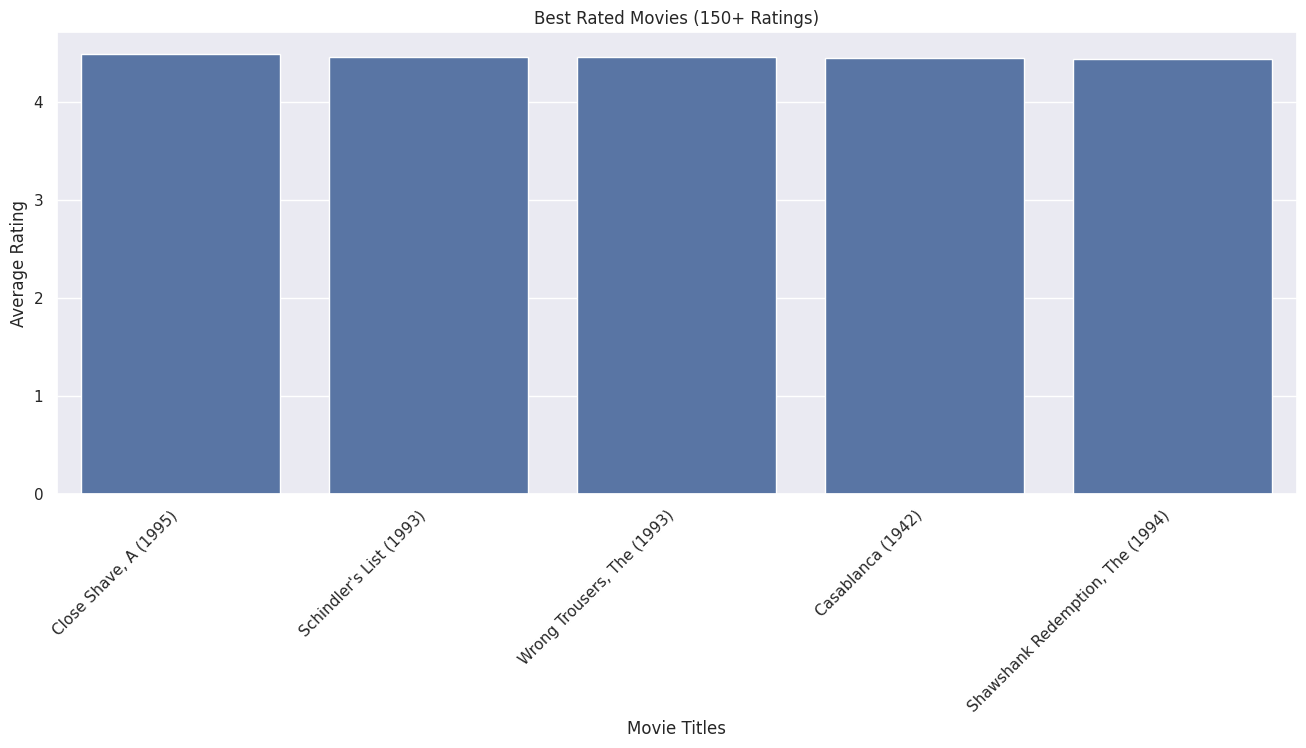

In [13]:
sns.set()
plt.figure(figsize=(16,6))
ax = sns.barplot(data=filter_150,
            x='title',
            y='mean')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Movie Titles")
plt.ylabel("Average Rating")

ax.set_title("Best Rated Movies (150+ Ratings)")

plt.show()